In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

from matplotlib import pyplot as plt
from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer
from vrAnalysis.helpers.plotting import save_figure
from vrAnalysis.sessions import B2Session
from dimensionality_manuscript.registry import PopulationRegistry, RegistryPaths
from dimensionality_manuscript.schematics.regression import plot_schematic, get_model_names, get_model_col_groups
from dimensionality_manuscript import (
    RegressionConfig,
    VectorGainRankConfig,
    RRRToExternalLatentsConfig,
    RegressionDimensionalitySweepConfig,
    RegressionPlacefieldResidualConfig,
    ResultsStore,
    ResultsAggregator,
)

# get session database
sessiondb = get_database("vrSessions")

# get population registry
registry = PopulationRegistry()

registry_paths = RegistryPaths()
figure_path = registry_paths.figure_path / "figure2"
if not figure_path.exists():
    figure_path.mkdir(parents=True, exist_ok=True)

In [2]:
sessions = sessiondb.iter_sessions(imaging=True, experimentType="Blender VR")
store = ResultsStore()

# Main results
cfg = RegressionConfig()
results = ResultsAggregator(cfg, store, sessions)

# Rank varying additive models (called VectorGain)
cfg_vector = VectorGainRankConfig()
results_vector = ResultsAggregator(cfg_vector, store, sessions)

# Regression dimensionality sweep 
cfg_sweep = RegressionDimensionalitySweepConfig()
results_sweep = ResultsAggregator(cfg_sweep, store, sessions)

# External to latents regressions
cfg = RRRToExternalLatentsConfig()
results_latents = ResultsAggregator(cfg, store, sessions)

# Place-field residual summaries
cfg_residual = RegressionPlacefieldResidualConfig()
results_residual = ResultsAggregator(cfg_residual, store, sessions)

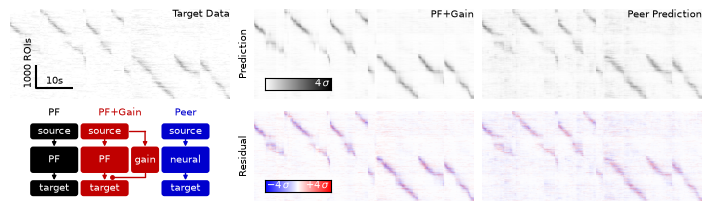

In [17]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelPredictionsFigureViewer, ModelZooSchematicConfig

cfg = ModelZooSchematicConfig(
    box_width=3.0,
    gain_width=1.75,
    col_gap=0.15,
    row_gap=0.45,
    arrow_linewidth=1.0,
    arrow_mutation_scale=6.00,
    box_fontsize=7,
    junction_dot_size=2.5,
    figsize=(2.5, 1.25),
)

show_viewer = False
viewer = ModelPredictionsFigureViewer(
    results,
    registry,
    mouse="ATL027",
    session="ATL027/2023-08-04/702",
    activity_parameters_name="std",
    xslice=slice(0, 364),
    vmax=4.0,
    scale_bar_x=0.12,
    scale_bar_y=0.12,
    scale_bar_seconds=10.0,
    scale_bar_num_rois=1000,
    colorscale_inset_rect=(0.05, 0.1, 0.3, 0.13),
    figsize=(7.0, 2.0),
    fontsize=7,
    zoo_config=cfg,
)
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_predictions_figure")

In [6]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelPerformanceViewer

viewer = ModelPerformanceViewer(
    results,
    spks_type = "sigrebase",
    activity_parameters_name = "std",
    metric = "r2",
    avg_by_mouse = True,
    reference_model = "internal_placefield_1d",
    include_structured_gain=False,
    ylim=(-0.01, 0.081),
    ytick_max = 0.07,
    legend_x = 5.0,
    legend_y = 0.085,
    legend_dy = -0.01,
    show_inset = True,
    figsize = (2.5, 1.75),
    fontsize = 7,
    inset_fontsize=7,
    inset_x=0.225,
    inset_y=0.45,
    inset_width=0.35,
    inset_height=0.45,
    inset_ytick_max=0.12,
    inset_ylim=(-0.02, 0.15),
    zero_line_pad=0.25,
)


show_viewer = True
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_performance_summary")

C:\Users\Andrew\Documents\GitHub\vrAnalysis\dimensionality_manuscript\pipeline\aggregate.py:44: RuntimeWarning: Mean of empty slice
  out[i] = np.nanmean(arr[mouse_names == mouse], axis=0)


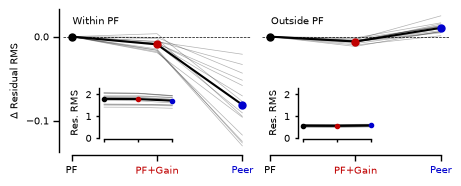

In [9]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelPlacefieldResidualViewer

viewer = ModelPlacefieldResidualViewer(
    results_residual,
    spks_type = "sigrebase",
    activity_parameters_name = "std",
    normalized=False,
    main_sharey=True,
    main_relative=True,
    within_text_x=0.05,
    outside_text_x=0.05,
    within_text_y=0.875,
    outside_text_y=0.875,
    inset_x=0.2,
    inset_y=0.1,
    inset_width=0.4,
    inset_show="all",
    inset_sharey=True,
    inset_relative=False,
    include_inset=True,
    figsize = (4.5, 1.75),
    fontsize = 7,
)

show_viewer = False
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_inoutplacefield_residual_summary")

c:\Users\Andrew\AppData\Local\miniforge3\envs\vrAnalysis\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmti10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


{'baseline_model': 'internal_placefield_1d',
 'comparison_models': ['internal_placefield_1d_gain', 'rrr'],
 'converged': True,
 'data':       mouse  session    model        r2
0    ATL012      0.0       pf  0.004360
1    ATL012      0.0  pf_gain  0.008349
2    ATL012      0.0     peer  0.082331
3    ATL012      1.0       pf  0.004657
4    ATL012      1.0  pf_gain  0.006462
..      ...      ...      ...       ...
415  ATL076     14.0  pf_gain  0.037251
416  ATL076     14.0     peer  0.067699
417  ATL076     15.0       pf  0.032815
418  ATL076     15.0  pf_gain  0.036833
419  ATL076     15.0     peer  0.062031

[420 rows x 4 columns],
 'estimation': 'REML',
 'fixed_effects':                               beta        se          z             p  \
Intercept                 0.017359  0.006956   2.495543  1.257644e-02   
model[T.pf_gain]          0.003984  0.004630   0.860579  3.894697e-01   
model[T.peer]             0.048420  0.004630  10.458035  1.346191e-25   
session                   

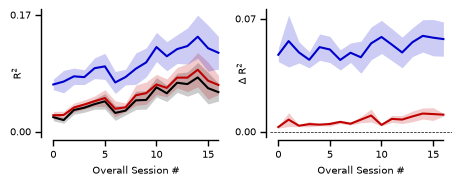

In [4]:
from dimensionality_manuscript.figure_scripts.figure2 import RegressionFamiliarityViewer

viewer = RegressionFamiliarityViewer(
    results,
    spks_type = "sigrebase",
    activity_parameters_name = "std",
    value_mode = "both",
    style = "errorPlot",
    se = True,
    min_mice = 2,
    auto_ylim = True,
    legend_options = dict(visible=False),
    show_zero_line=True,
    figsize = (4.5, 1.75),
    fontsize = 7,
)

report_stats = True
if report_stats:
    from pprint import pprint
    stats = viewer.measure_statistics(viewer.state)
    pprint(stats)

show_viewer = False
if show_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "regression_by_familiarity")

In [17]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelPlacefieldResidualFamiliarityViewer

show_viewer = True
viewer = ModelPlacefieldResidualFamiliarityViewer(
    results_residual,
    activity_parameters_name = "std",
    normalized=False,
    quality=False,
    sharey=True,
    relative=True,
    within_only=False,
    figsize = (4.5, 1.75),
    fontsize = 7,
    legend_options = dict(
        loc="lower left",
        fontsize_scale=1.0,
    )
)
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_placefield_residual_familiarity")

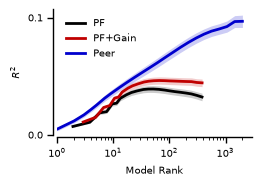

In [8]:
from dimensionality_manuscript.figure_scripts.figure2 import RegressionDimSweepViewer

show_viewer = False
viewer = RegressionDimSweepViewer(
    results_sweep,
    activity_parameters_name="std",
    metric = "r2",
    se = True,
    xlog = True,
    linewidth = 2.0,
    fill_alpha = 0.2,
    figsize = (2.5, 1.75),
    fontsize = 7,
)
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "regression_dim_sweep")

In [ ]:
from dimensionality_manuscript.figure_scripts.figure2 import DimSweepLatentsViewer

show_viewer = True
viewer = DimSweepLatentsViewer(
    results_latents,
    results_sweep,
    latents_show = "internal",
    metric = "r2",
    se = True,
    xlog = True,
    linewidth = 2.0,
    fill_alpha = 0.1,
    figsize = (4.5, 2.5),
    fontsize = 8,
)
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "dim_sweep_latents")

In [ ]:
from dimensionality_manuscript.figure_scripts.figure2 import RRRExternalLatentsViewer

show_viewer = True
viewer = RRRExternalLatentsViewer(
    results_latents,
    normalize = False,
    agg_method = "median",
    latents_show = "internal",
    beewidth = 0.25,
    dodge_offset = 0.2,
    width_rank_axis = 0.8,
    rank_axis_log = False,
    inset_num_dims = 20,
    figsize = (5.0, 3.0),
    alpha = 0.4,
    fontsize = 8,
)
if show_viewer:
    viewer.show()
else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "rrr_to_external_latents_score")

In [ ]:
from dimensionality_manuscript.figure_scripts.figure2 import ModelZooCondensed, ModelZooSchematicConfig

show_viewer = False
cfg = ModelZooSchematicConfig(
    gain_width=1.0,
    col_gap=0.15,
    row_gap=0.45,
    arrow_linewidth=1.0,
    arrow_mutation_scale=6.00,
    box_fontsize=7,
    junction_dot_size=2.5,
    figsize=(2.5, 1.25),
)
viewer = ModelZooCondensed(cfg)
if show_viewer:
    viewer.show()

else:
    fig = viewer.plot(viewer.state)
    plt.show()

    save = True
    if save:
        save_figure(fig, figure_path / "model_zoo_condensed")

In [ ]:
from dimensionality_manuscript.figure_scripts.figure2 import RegressionPredictionViewer

viewer = RegressionPredictionViewer(
    results,
    registry,
    model_name="external_placefield_1d",
)
# viewer.show()

In [ ]:
# Make a stack of rasterplots
from dimensionality_manuscript.figure_scripts.figure2 import ModelRasterFocus

mouse_name = "ATL027"
date = "2023-08-07"#"2023-07-27"
session_id = "701"
spks_type = "sigrebase"
session = B2Session.create(mouse_name, date, session_id, dict(spks_type=spks_type))

model_names = ["internal_placefield_1d", "internal_placefield_1d_gain", "rrr"]
fig_props = dict(
    activity_parameters_name="std",
    include_data_raster=True,
    include_error_column=True,
    include_sample_fit_curve=False,
    sample_fit_metric="r2",
    zscore=False,
    subtract_median=False,
    xslice=slice(0, 400),
    vmax=5.0,
    figsize=(6.0, 3.5),
    scale_bar_seconds=20.0,
)
viewer = ModelRasterFocus(session, spks_type, model_names, registry=registry, **fig_props)
# viewer.show()

# save_figure(viewer.plot(viewer.state), figure_path / "stacked_model_rasters")